In [ ]:
import os
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import multiprocessing
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_fscore_support, accuracy_score, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from scipy.stats import ks_2samp
import joblib
from collections import defaultdict, Counter

SEED = 42

In [ ]:
num_cores = multiprocessing.cpu_count()
os.environ["OMP_NUM_THREADS"] = str(num_cores)
os.environ["MKL_NUM_THREADS"] = str(num_cores)
print(num_cores)
print(torch.version.cuda, torch.cuda.is_available(), torch.backends.cudnn.enabled)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

species = "Homo_sapiens"
species_space = species.replace("_", " ")

if not os.path.exists(species):
    os.makedirs(species)
    print(f"Directory '{species}' created.")
else:
    print(f"Directory '{species}' already exists.")

window_size = 400
window_abbr = "0.4"
print(f"window_size: {window_size}")
half_window_size = window_size // 2


pre_chromosome_mapping = {
    'NC_000001.11': 'chr1', 
    'NC_000002.12': 'chr2', 
    'NC_000003.12': 'chr3', 
    'NC_000004.12': 'chr4', 
    'NC_000005.10': 'chr5', 
    'NC_000006.12': 'chr6', 
    'NC_000007.14': 'chr7', 
    'NC_000008.11': 'chr8', 
    'NC_000009.12': 'chr9', 
    'NC_000010.11': 'chr10', 
    'NC_000011.10': 'chr11', 
    'NC_000012.12': 'chr12', 
    'NC_000013.11': 'chr13', 
    'NC_000014.9': 'chr14', 
    'NC_000015.10': 'chr15', 
    'NC_000016.10': 'chr16', 
    'NC_000017.11': 'chr17', 
    'NC_000018.10': 'chr18', 
    'NC_000019.10': 'chr19', 
    'NC_000020.11': 'chr20', 
    'NC_000021.9': 'chr21', 
    'NC_000022.11': 'chr22', 
    'NC_000023.11': 'chrX', 
    'NC_000024.10': 'chrY'
}

chromosome_mapping = {value: key for key, value in pre_chromosome_mapping.items()}

# Filter for only placed sequences
chroms = list(range(1, 23)) + ['X', 'Y']
chrom_list = [f'chr{chrom}' for chrom in chroms]

subset_str = 'combined_t'

### Data pre-processing

In [ ]:
data = pd.read_csv(f"{species}/{species}_balanced_data_{window_abbr}kb_annotated.csv")
print(f"data.shape: {data.shape}")

feature_cols = ['chrom', 'sequence', 'label', 'sv_type', 'sv_len', 'pos', 'end',
       'left_start', 'left_end', 'right_start', 'right_end', 'num_del',
       'num_ins', 'num_inv', 'num_smalldel', 'num_smallins', 'gc_content',
       'full_snp_count', 'distance_to_exon', 'distance_to_Alu/SINE',
       'distance_to_L1/LINE', 'distance_to_L2/LINE', 
       'distance_to_Low_complexity/Low_complexity', 'distance_to_MIR/SINE', 'distance_to_Satellite/Satellite',
       'distance_to_Simple_repeat/Simple_repeat',
       'avg_phyloP_scores', 'avg_recomb_rate_full', 'avg_cCRE_full',
       'avg_DNase_score_full', 'avg_tf_score_full']

balanced_data = data[feature_cols].copy()
balanced_data['num_ins_del'] = balanced_data['num_ins'] + balanced_data['num_del']
balanced_data['num_small_indel'] = balanced_data['num_smallins'] + balanced_data['num_smalldel']
balanced_data.drop(['num_ins', 'num_del', 'num_smallins', 'num_smalldel', 'left_end', 'right_start'], inplace=True, axis=1)

balanced_data.rename({
    'num_small_indel': 'Number of small indels',
    'num_ins_del': 'Number of large insertions and deletions',
    'num_inv': 'Number of inversions',
    'gc_content': 'GC content',
    'distance_to_Alu/SINE': 'Distance to nearest Alu/SINE',
    'distance_to_L1/LINE': 'Distance to nearest L1/LINE',
    'distance_to_L2/LINE': 'Distance to nearest L2/LINE',
    'distance_to_MIR/SINE': 'Distance to nearest MIR/SINE',
    'distance_to_Simple_repeat/Simple_repeat': 'Distance to nearest simple repeat',
    'distance_to_exon': 'Distance to nearest exon',
    'distance_to_Satellite/Satellite': 'Distance to nearest satellite',
    'distance_to_Low_complexity/Low_complexity': 'Distance to nearest low complexity repeat',
    'avg_phyloP_scores': 'Average phyloP score',
    'full_snp_count': 'Number of SNPs',
    'avg_DNase_score_full': 'Average DNase accessibility score',
    'avg_cCRE_full': 'Average cCRE score',
    'avg_tf_score_full': 'Average transcription factor peak',
    'avg_recomb_rate_full': 'Average recombination rate'
}, axis=1, inplace=True)

balanced_data

,chrom,sequence,label,sv_type,sv_len,pos,end,left_start,right_end,Number of inversions,...,Distance to nearest MIR/SINE,Distance to nearest satellite,Distance to nearest simple repeat,Average phyloP score,Average recombination rate,Average cCRE score,Average DNase accessibility score,Average transcription factor peak,Number of large insertions and deletions,Number of small indels
0,chr3,CTTCTGTATATTTGCTTTTGTTGATACCAGACATCCAAAATCTTGA...,0,nonSV,0,2744425,2744425,2744225,2744625,0,...,200,200,200,0.029578,3.032530e-01,0.000000,0.0,0.0,0,1
1,chr11,CCCACTAGCTAAATCAGGAGCGTTAGCAGCTTAACTCTCTGAGCCT...,0,nonSV,0,114175197,114175197,114174997,114175397,0,...,0,200,200,0.061210,6.306368e-01,3.336641,129.5,0.0,0,0
2,chr11,ATATACATAAGTGTATATATATAAGTGTATATATATACATAAGTGT...,1,INS,66,122018191,122018192,122017991,122018392,0,...,200,200,200,-0.113113,2.714780e-03,0.000000,0.0,0.0,3,13
3,chr5,TTGTAAGTATATTATGTTTGTAATACACAGGGAAATTAAAGGGCCA...,0,nonSV,0,170842269,170842269,170842069,170842469,0,...,200,200,200,0.365475,4.325920e-02,0.000000,0.0,0.0,0,0
4,chrX,AGCTCTTGGCCACTAAAGCCAATTCTCTTGTCTCCTATTTTTTTTT...,1,INS,134,107501516,107501517,107501316,107501717,0,...,200,200,200,0.102012,1.292860e+00,0.000000,0.0,0.0,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347643,chr4,ACGATAGGGAAAATCAGGGTCTCTGTGTAGTTAATCTGTGTGACTC...,1,DEL,115,188447480,188447595,188447280,188447795,0,...,200,200,200,-0.073255,1.033230e-01,0.000000,64.0,31.8,5,5
347644,chr9,AAGATTATTCTAAAATGCATATGTAAAGGCAAAGTAACTGGAATAG...,0,nonSV,0,6571315,6571315,6571115,6571515,0,...,200,200,200,0.097435,1.052120e-01,0.000000,0.0,0.0,0,2
347645,chr6,AAATGAAGGTAGAGATCAATGCTCACAGGTCTAATAACAGCTTAGG...,1,INS,177,25091702,25091703,25091502,25091903,0,...,200,200,200,0.120217,5.605190e-45,0.000000,50.5,0.0,0,1
347646,chr7,CACAGATCAGGCCATTCTATCCACTTGATTATTAAAATTCTCCTCT...,1,INS,62,114905999,114906000,114905799,114906200,0,...,200,200,7,-0.002855,1.826690e-19,0.000000,0.0,0.0,0,0


In [ ]:
# original SV dataframe to add TE annotations
sv_insdel = pd.read_csv(
    "../HGSVC3/annotation_table/variants_GRCh38_sv_insdel_HGSVC2024v1.0.tsv",
    sep="\t"
)

te_df = sv_insdel[["#CHROM", "POS", "END", "SVTYPE", "SVLEN", "TE"]].copy()
te_df = te_df.rename(columns={"#CHROM": "chrom"})
te_df["POS"] = te_df["POS"] - 1
te_df["END"] = te_df["END"] - 1
te_df["sv_type"] = te_df["SVTYPE"].astype(str)
te_df["sv_len"] = te_df["SVLEN"].abs().astype(int)
te_df = te_df.rename(columns={
    "POS": "pos",
    "END": "end"
})

balanced_data = balanced_data.merge(
    te_df[["chrom", "pos", "end", "sv_type", "sv_len", "TE"]],
    on=["chrom", "pos", "end", "sv_type", "sv_len"],
    how="left"
)

balanced_data["TE"] = balanced_data["TE"].fillna("nonTE")
balanced_data["TE"].value_counts(dropna=False)

ins_df = pd.read_csv("insertion_repeatmasker.csv")
del_df = pd.read_csv("deletion_repeatmasker.csv")
repeat_df = pd.concat([ins_df, del_df], ignore_index=True)
columns_to_use = ['ID', 'CHROM', 'POS', 'END', 'SVTYPE', 'SVLEN', 'REPEAT_TYPE', 'REPEAT_GROUP']
repeat_df = repeat_df[columns_to_use] 
repeat_df["POS"] = repeat_df["POS"] - 1
repeat_df["END"] = repeat_df["END"] - 1

balanced_data = balanced_data.merge(
    repeat_df[
        ["CHROM", "POS", "END", "SVTYPE", "SVLEN", "REPEAT_GROUP"]
    ].rename(columns={
        "CHROM": "chrom",
        "POS": "pos",
        "END": "end",
        "SVTYPE": "sv_type",
        "SVLEN": "sv_len"
    }),
    on=["chrom", "pos", "end", "sv_type", "sv_len"],
    how="left"
)

balanced_data["REPEAT_GROUP"] = (
    balanced_data["REPEAT_GROUP"]
    .fillna("nonRepeat")
)

In [ ]:
mapping = {'A': [1, 0, 0, 0], 'T': [0, 1, 0, 0], 'C': [0, 0, 1, 0], 'G': [0, 0, 0, 1], 'N': [0, 0, 0, 0]}

def one_hot_encode(seq, mapping):
    return np.array([mapping[ch] for ch in seq])

def get_middle(seq):
    center = len(seq) // 2
    start = max(center - 500, 0)
    end = start + 1000
    return seq[start:end]

X_categorical = np.array([one_hot_encode(seq, mapping) for seq in balanced_data['sequence']])
y = balanced_data['label'].values
indices = np.arange(len(y))

num_feature_cols = ['Number of large insertions and deletions',
       'Number of small indels', 'Number of inversions', 'GC content',
       'Number of SNPs', 'Distance to nearest exon', 'Distance to nearest Alu/SINE',
       'Distance to nearest L1/LINE', 'Distance to nearest L2/LINE', 
       'Distance to nearest low complexity repeat', 'Distance to nearest MIR/SINE', 'Distance to nearest satellite',
       'Distance to nearest simple repeat',
       'Average phyloP score', 'Average recombination rate', 'Average cCRE score',
       'Average DNase accessibility score', 'Average transcription factor peak']

X_numerical = balanced_data[num_feature_cols].astype(float).to_numpy()
print(X_categorical.shape, X_numerical.shape, y.shape)

(347648, 400, 4) (347648, 18) (347648,)


In [9]:
X_train_val, X_test, y_train_val, y_test, X_num_train_val, X_num_test, train_val_idx, test_idx = train_test_split(
    X_categorical, y, X_numerical, indices, test_size=0.20, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val, X_num_train, X_num_val, train_idx, val_idx = train_test_split(
    X_train_val, y_train_val, X_num_train_val, train_val_idx, test_size=0.25, random_state=SEED, stratify=y_train_val
)

scaler = StandardScaler()
scaler.fit(X_num_train)
joblib.dump(scaler, f"{species}/{species}_{window_abbr}kb_scaler.pkl")

X_num_train_scaled = scaler.transform(X_num_train)
X_num_val_scaled = scaler.transform(X_num_val)
X_num_test_scaled = scaler.transform(X_num_test)

X_cat_train_tensor = torch.tensor(X_train, dtype=torch.float32).permute(0, 2, 1)
X_cat_val_tensor = torch.tensor(X_val, dtype=torch.float32).permute(0, 2, 1)
X_cat_test_tensor = torch.tensor(X_test, dtype=torch.float32).permute(0, 2, 1)

X_num_train_tensor = torch.tensor(X_num_train_scaled, dtype=torch.float32)
X_num_val_tensor = torch.tensor(X_num_val_scaled, dtype=torch.float32)
X_num_test_tensor = torch.tensor(X_num_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

train_data = TensorDataset(X_cat_train_tensor, X_num_train_tensor, y_train_tensor)
val_data = TensorDataset(X_cat_val_tensor, X_num_val_tensor, y_val_tensor)
test_data = TensorDataset(X_cat_test_tensor, X_num_test_tensor, y_test_tensor)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)
test_loader = DataLoader(test_data, batch_size=128)

print("X_cat_train_tensor.shape, X_num_train_tensor.shape, y_train_tensor.shape")
print(X_cat_train_tensor.shape, X_num_train_tensor.shape, y_train_tensor.shape)

X_cat_train_tensor.shape, X_num_train_tensor.shape, y_train_tensor.shape
torch.Size([208588, 4, 400]) torch.Size([208588, 18]) torch.Size([208588, 1])


In [ ]:
balanced_scaled = balanced_data.copy()

for col_i, col in enumerate(num_feature_cols):
    balanced_scaled.loc[train_idx, col] = X_num_train_scaled[:, col_i]
    balanced_scaled.loc[val_idx, col] = X_num_val_scaled[:, col_i]
    balanced_scaled.loc[test_idx, col] = X_num_test_scaled[:, col_i]


plot_columns = num_feature_cols

fig, ax = plt.subplots(figsize=(10, len(plot_columns) * 0.4))

positions = np.arange(0, len(plot_columns) * 3, 3)
colors = {0: '#4682B4', 1: 'orange'}
median_marker = {'marker': 'o', 'markersize': 6, 'linestyle': ''}

legend_added = set()

for i, col in enumerate(plot_columns):
    data_grouped = balanced_scaled.groupby('label')[col].apply(
        lambda x: [np.nanmedian(x), np.nanpercentile(x, 25), np.nanpercentile(x, 75)]
    ).reset_index()

    for j, group in enumerate(sorted(balanced_scaled['label'].dropna().unique())):
        median, p25, p75 = data_grouped[data_grouped['label'] == group][col].iloc[0]
        group_pos = positions[i] + (j - 0.5) * 0.6
        current_color = colors.get(group, '#555555')

        ax.plot([p25, p75], [group_pos, group_pos], color=current_color, linestyle='-', linewidth=3)
        ax.plot(median, group_pos, color=current_color, **median_marker)

        if group not in legend_added:
            ax.plot([], [], color=current_color, **median_marker,
                    label=('Background' if group == 0 else 'SV region'))
            legend_added.add(group)

ax.set_yticks(positions)
ax.set_yticklabels(plot_columns)
plt.legend(title='Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title(f'Feature Statistics: SV Regions vs Background with {window_abbr}kb Context')
plt.ylabel('Feature')
plt.xlabel('Normalized Value')
plt.tight_layout()
plt.savefig(f"{species}/{species}_{window_abbr}kb_feature_distribution_new_{subset_str}.png")
plt.show()

### Random Forest Classifier and Feature Importances

In [ ]:
remove = []
columns_to_keep = [c for c in num_feature_cols if c not in remove]

col2idx = {c: i for i, c in enumerate(num_feature_cols)}
indices_to_keep = [col2idx[c] for c in columns_to_keep]

X_train_full_pre = np.vstack((X_num_train_scaled, X_num_val_scaled))[:, indices_to_keep]
y_train_full_pre = np.concatenate((y_train, y_val))

X_test_filtered_pre = X_num_test_scaled[:, indices_to_keep]

rfc_pre = RandomForestClassifier(
    n_estimators=1000,
    random_state=SEED,
    n_jobs=-1,
    class_weight=None  
)
rfc_pre.fit(X_train_full_pre, y_train_full_pre)
joblib.dump(rfc_pre, f"{species}/{species}_{window_abbr}kb_rfc_pre.pkl")

y_pred_pre = rfc_pre.predict(X_test_filtered_pre)
y_probs_pre = rfc_pre.predict_proba(X_test_filtered_pre)[:, 1]

acc  = accuracy_score(y_test, y_pred_pre)
prec = precision_score(y_test, y_pred_pre)
rec  = recall_score(y_test, y_pred_pre)
f1   = f1_score(y_test, y_pred_pre)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

fpr, tpr, _ = roc_curve(y_test, y_probs_pre)
roc_auc = auc(fpr, tpr)
print("ROC AUC:", roc_auc)

pr_precision, pr_recall, _ = precision_recall_curve(y_test, y_probs_pre)
pr_auc = average_precision_score(y_test, y_probs_pre)

roc_pr_data_file = f"{species}/{species}_{window_abbr}kb_roc_pr_data_rf_no_cnn_{subset_str}.npz"
np.savez(
    roc_pr_data_file,
    fpr=fpr, tpr=tpr, roc_auc=roc_auc,
    precision=pr_precision, recall=pr_recall, pr_auc=pr_auc
)
print(f"[saved] {roc_pr_data_file}")

# feature importances
importances = rfc_pre.feature_importances_
fi_df = pd.DataFrame({"Feature": columns_to_keep, "Importance": importances}) \
          .sort_values("Importance", ascending=False)

fi_path = f"{species}/{species}_balanced_{window_abbr}kb_rf_feature_importances_{subset_str}.csv"
fi_df.to_csv(fi_path, index=False)
print(f"[saved] {fi_path}")

plt.figure(figsize=(6, 8))
plt.barh(
    fi_df['Feature'].iloc[:20][::-1], 
    fi_df['Importance'].iloc[:20][::-1], 
    color='blue',  
    alpha=0.6,  
    edgecolor='black'  
)
plt.xlabel('Importance Score', fontsize=9)
plt.ylabel('Feature', fontsize=9)
plt.yticks(fontsize=9)
plt.title(f'Top Feature Importances for {species_space} with {window_abbr}kb Context', fontsize=10)
plt.tight_layout()
plt.savefig(f"{species}/{species}_{window_abbr}kb_feature_importances_noCNN_{subset_str}.pdf", format='pdf', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
perm_result = permutation_importance(
    rfc_pre,
    X_test_filtered_pre,
    y_test,
    n_repeats=5,
    random_state=SEED,
    n_jobs=1
)

perm_df = pd.DataFrame({
    "Feature": columns_to_keep,
    "Permutation_Importance_Mean": perm_result.importances_mean,
    "Permutation_Importance_STD": perm_result.importances_std
}).sort_values("Permutation_Importance_Mean", ascending=False)

perm_file = f"{species}/{species}_balanced_{window_abbr}kb_rf_permutation_importances_{subset_str}.csv"
perm_df.to_csv(perm_file, index=False)
print(f"[saved] {perm_file}")

plt.figure(figsize=(6, 8))
plt.barh(
    perm_df['Feature'].iloc[:20][::-1],
    perm_df['Permutation_Importance_Mean'].iloc[:20][::-1], 
    color='blue',
    alpha=0.6,
    edgecolor='black' 
)
plt.xlabel('Importance Score', fontsize=9)
plt.ylabel('Feature', fontsize=9)
plt.yticks(fontsize=9)
plt.title(f'Top Permutation Importances for {species_space} with {window_abbr}kb Context', fontsize=10)
plt.tight_layout()
plt.savefig(f"{species}/{species}_{window_abbr}kb_permnutation_importances_noCNN_{subset_str}.pdf", format='pdf', bbox_inches='tight', dpi=300)
plt.show()

### Baseline Logistic Regression Classifier

In [ ]:
lr_model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=SEED)
lr_model.fit(X_train_full_pre, y_train_full_pre)

y_pred_lr = lr_model.predict(X_test_filtered_pre)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression - Accuracy:", accuracy_lr)
print("Logistic Regression - Precision:", precision_lr)
print("Logistic Regression - Recall:", recall_lr)
print("Logistic Regression - F1 Score:", f1_lr)

y_probs_lr = lr_model.predict_proba(X_test_filtered_pre)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_probs_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
print("Logistic Regression - ROC AUC:", roc_auc_lr)

precision_vals_lr, recall_vals_lr, _ = precision_recall_curve(y_test, y_probs_lr)
pr_auc_lr = average_precision_score(y_test, y_probs_lr)

roc_pr_data_file_lr = f"{species}/{species}_{window_abbr}kb_roc_pr_data_logreg_without_CNN_{subset_str}.npz"
np.savez(
    roc_pr_data_file_lr,
    fpr=fpr_lr,
    tpr=tpr_lr,
    roc_auc=roc_auc_lr,
    precision=precision_vals_lr,
    recall=recall_vals_lr,
    pr_auc=pr_auc_lr
)

print(f"ROC/PR data saved for Logistic Regression to: {roc_pr_data_file_lr}")

In [ ]:
coef_df = pd.DataFrame({
    "feature": num_feature_cols,
    "coefficient": lr_model.coef_[0]
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

top_n = 20

plot_df = coef_df.sort_values(
    "abs_coefficient",
    ascending=False
).head(top_n)

plt.figure(figsize=(8, 6))

colors = np.where(
    plot_df["coefficient"] > 0,
    "#DD8452",
    "#4C72B0"
)

plt.barh(
    plot_df["feature"],
    plot_df["coefficient"],
    color=colors
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Logistic Regression Coefficient")
plt.title("Top Logistic Regression Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f"{species}/{species}_{window_abbr}kb_LR_coeff_{subset_str}.png")
plt.show()

### Convolutional Neural Network

In [ ]:
from model import SV_CNN

n = 2
num_layers = f"{n}"
print(f"n: {num_layers}")

model = SV_CNN(4, 1)
if torch.cuda.is_available():
    model.to(device)
print(device)
print(model)

n: 2
cpu
SV_CNN(
  (initial): Sequential(
    (0): Conv1d(4, 128, kernel_size=(1,), stride=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layers): ModuleList(
    (0-2): 3 x ResidualBlock(
      (conv1): Conv1d(128, 128, kernel_size=(11,), stride=(1,), padding=(5,))
      (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (conv2): Conv1d(128, 128, kernel_size=(11,), stride=(1,), padding=(5,))
      (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (final_conv): Conv1d(128, 32, kernel_size=(1,), stride=(1,))
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=12800, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)


### Training

In [ ]:
# Loss function, optimizer, and scheduler
criterion = nn.BCELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-6, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True
)

# Training loop
num_epochs = 150
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience = 5
counter = 0

for epoch in range(num_epochs):    
    model.train()
    train_loss = 0.0
    for X_cat, _, y_label in train_loader:  
        if torch.cuda.is_available():
            X_cat = X_cat.to(device)
            y_label = y_label.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_cat)
        loss = criterion(outputs, y_label)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_cat, _, y_label in val_loader:
            if torch.cuda.is_available():
                X_cat = X_cat.to(device)
                y_label = y_label.to(device)
            outputs = model(X_cat)
            loss = criterion(outputs, y_label)
            val_loss += loss.item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)

    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), f"{species}/{species}_{window_abbr}kb_best_model_{num_layers}_{subset_str}.pt")  # Save the best model
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='red', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.savefig(f"{species}/{species}_{window_abbr}kb_training_curves_{num_layers}_{subset_str}.png")
plt.show()


# Testing
model.load_state_dict(torch.load(f"{species}/{species}_{window_abbr}kb_best_model_{num_layers}_{subset_str}.pt", map_location=torch.device(device)))
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

y_pred_proba = []
y_true = []

with torch.no_grad():
    for X_cat, _, y_label in test_loader:
        if torch.cuda.is_available():
            X_cat = X_cat.to(device)
        outputs = model(X_cat).squeeze()
        probabilities = outputs.cpu().numpy()
        predicted = (outputs > 0.5).float()
        y_true.extend(y_label.cpu().numpy())
        y_pred_proba.extend(probabilities)

y_pred_proba = np.array(y_pred_proba) 
y_pred = (y_pred_proba > 0.5).astype(int)
y_true = np.array(y_true)

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
pr_auc = average_precision_score(y_true, y_pred_proba)

print(f"roc_auc: {roc_auc}, pr_auc: {pr_auc}")

roc_pr_data_file = f"{species}/{species}_{window_abbr}kb_roc_pr_data_CNN_{num_layers}_{subset_str}.npz"
np.savez(roc_pr_data_file, fpr=fpr, tpr=tpr, roc_auc=roc_auc,
         precision=precision, recall=recall, pr_auc=pr_auc)

print(f"ROC/PR data saved for CNN to: {roc_pr_data_file}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label="Random Classifier")
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title(f'CNN Receiver Operating Characteristic (ROC) Curve for {species_space}')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{species}/{species}_{window_abbr}kb_roc_curve_CNN_{num_layers}_{subset_str}.png")
print("ROC curve saved")
plt.show()

### CNN representation analyses

In [ ]:
model.load_state_dict(torch.load(f"{species}/{species}_{window_abbr}kb_best_model_{num_layers}_{subset_str}.pt", map_location=torch.device(device)))
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
embeddings = []
probs = []
labels = []

with torch.no_grad():
    for X_cat, X_num, y_label in test_loader:
        X_cat = X_cat.to(device)

        emb = model.extract_features(X_cat)
        pred = model(X_cat)

        embeddings.append(emb.cpu().numpy())
        probs.append(pred.cpu().numpy())
        labels.append(y_label.cpu().numpy())

embeddings = np.vstack(embeddings)
probs = np.vstack(probs).ravel()
labels = np.vstack(labels).ravel().astype(int)

print("Embeddings:", embeddings.shape)

In [ ]:
# Metadata for test set
test_meta = balanced_data.iloc[test_idx].reset_index(drop=True).copy()

test_meta["label"] = labels
test_meta["pred_proba"] = probs
test_meta["pred_label"] = (probs > 0.5).astype(int)

In [ ]:
# PCA on embeddings
emb_scaled = StandardScaler().fit_transform(embeddings)

pca = PCA(n_components=20, random_state=SEED)
pcs = pca.fit_transform(emb_scaled)

for i in range(pcs.shape[1]):
    test_meta[f"PC{i+1}"] = pcs[:, i]

print("Explained variance:")
for i, v in enumerate(pca.explained_variance_ratio_[:10], start=1):
    print(f"PC{i}: {v:.3f}")

In [ ]:
label_colors = {
    0: "#4C72B0", # Background
    1: "#DD8452" # SV
}

fig = plt.figure(figsize=(8, 8))

ax_scatter = fig.add_axes([0.1, 0.1, 0.65, 0.65])
ax_xdens = fig.add_axes([0.1, 0.80, 0.65, 0.15], sharex=ax_scatter)
ax_ydens = fig.add_axes([0.77, 0.1, 0.15, 0.65], sharey=ax_scatter)

for label, name in [(0, "Background"), (1, "SV")]:

    sub = test_meta[test_meta["label"] == label]

    ax_scatter.scatter(
        sub["PC1"],
        sub["PC2"],
        s=10,
        alpha=0.4,
        edgecolors="none",
        color=label_colors[label],
        label=f"{name} (n={len(sub)})"
    )

    ax_xdens.hist(
        sub["PC1"],
        bins=50,
        density=True,
        histtype="step",
        linewidth=2,
        color=label_colors[label]
    )

    ax_ydens.hist(
        sub["PC2"],
        bins=50,
        density=True,
        histtype="step",
        linewidth=2,
        orientation="horizontal",
        color=label_colors[label]
    )

ax_scatter.set_xlabel("PC1", fontsize=12)
ax_scatter.set_ylabel("PC2", fontsize=12)
ax_scatter.set_title("CNN Embeddings PCA", fontsize=14)

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label='Background',
           markerfacecolor=label_colors[0],
           markersize=8),

    Line2D([0], [0], marker='o', color='w',
           label='SV',
           markerfacecolor=label_colors[1],
           markersize=8)
]

ax_scatter.legend(handles=legend_elements, frameon=True)
ax_xdens.axis("off")
ax_ydens.axis("off")

plt.savefig(f"{species}/{species}_{window_abbr}kb_CNN_emb_label_{subset_str}.pdf",
            format='pdf', bbox_inches='tight', dpi=300)
plt.show()

for pc in ["PC1", "PC2"]:
    stat, p = ks_2samp(
        test_meta.loc[test_meta["label"] == 0, pc],
        test_meta.loc[test_meta["label"] == 1, pc]
    )
    print(f"{pc}: KS={stat:.3f}, p={p:.2e}")

In [ ]:
# embeddings colored by repeat group
def plot_pca_te_repeat(df, max_categories=10):
    plot_df = df[df["label"] == 1].copy()

    plot_df["group"] = np.where(
        plot_df["TE"].fillna("nonTE") != "nonTE",
        plot_df["TE"].astype(str),
        plot_df["REPEAT_GROUP"].fillna("Non-repetitive").astype(str)
    )

    plot_df["group"] = plot_df["group"].apply(rename_group_label)

    top_groups = plot_df["group"].value_counts().head(max_categories).index

    plot_df["group_plot"] = plot_df["group"].where(
        plot_df["group"].isin(top_groups),
        "Other"
    )

    groups = plot_df["group_plot"].unique()
    cmap = plt.get_cmap("tab20")

    color_map = {
        g: cmap(i % 20)
        for i, g in enumerate(groups)
    }

    fig = plt.figure(figsize=(8, 8))

    ax_scatter = fig.add_axes([0.1, 0.1, 0.65, 0.65])
    ax_xdens = fig.add_axes([0.1, 0.80, 0.65, 0.15], sharex=ax_scatter)
    ax_ydens = fig.add_axes([0.77, 0.1, 0.15, 0.65], sharey=ax_scatter)

    for g in groups:
        sub = plot_df[plot_df["group_plot"] == g]

        ax_scatter.scatter(
            sub["PC1"],
            sub["PC2"],
            s=14,
            alpha=0.6,
            edgecolors="none",
            color=color_map[g],
            label=f"{g} (n={len(sub)})"
        )

        ax_xdens.hist(
            sub["PC1"],
            bins=50,
            density=True,
            histtype="step",
            linewidth=1.5,
            color=color_map[g]
        )

        ax_ydens.hist(
            sub["PC2"],
            bins=50,
            density=True,
            histtype="step",
            linewidth=1.5,
            orientation="horizontal",
            color=color_map[g]
        )

    ax_scatter.set_xlabel("PC1", fontsize=12)
    ax_scatter.set_ylabel("PC2", fontsize=12)

    ax_scatter.set_title(
        "SV CNN Embeddings PCA Colored by TE / Repeat Group",
        fontsize=14
    )

    ax_scatter.legend(
        bbox_to_anchor=(1.35, 1),
        loc="upper left",
        frameon=True,
        fontsize=9
    )

    ax_xdens.axis("off")
    ax_ydens.axis("off")

    plt.savefig(f"{species}/{species}_{window_abbr}kb_CNN_emb_subclasses_{subset_str}.pdf", format='pdf', bbox_inches='tight', dpi=300)
    plt.show()

def rename_group_label(x):
    x = str(x)

    if x in ["nonRepeat", "Non-repetitive"]:
        return "Non-repetitive"

    return x.replace("_", " ")

plot_pca_te_repeat(test_meta)

In [ ]:
def plot_each_highlight_group(df):
    plot_df = df[df["label"] == 1].copy()

    plot_df["group"] = np.where(
        plot_df["TE"].fillna("nonTE") != "nonTE",
        plot_df["TE"].astype(str),
        plot_df["REPEAT_GROUP"].fillna("Non-repetitive").astype(str)
    )

    plot_df["group"] = plot_df["group"].apply(rename_group_label)

    # collapse uncommon groups
    major_groups = [
        "SINE/Alu",
        "LINE/L1",
        "Retroposon/SVA",
        "Simple repeat",
        "Non-repetitive"
    ]

    plot_df["group_plot"] = plot_df["group"].where(
        plot_df["group"].isin(major_groups),
        "Others"
    )

    highlight_groups = major_groups + ["Others"]

    color_map = {
        "SINE/Alu": "#E15759",
        "LINE/L1": "#4E79A7",
        "Retroposon/SVA": "#59A14F",
        "Simple repeat": "#F28E2B",
        "Non-repetitive": "#B07AA1",
        "Others": "#9D9D9D"
    }

    for g in highlight_groups:
        plt.figure(figsize=(6, 5))

        bg = plot_df[plot_df["group_plot"] != g]
        sub = plot_df[plot_df["group_plot"] == g]

        plt.scatter(
            bg["PC1"],
            bg["PC2"],
            s=9,
            alpha=0.10,
            color="lightgray",
            edgecolors="none",
            label="Other SVs"
        )

        plt.scatter(
            sub["PC1"],
            sub["PC2"],
            s=18,
            alpha=0.85,
            color=color_map[g],
            edgecolors="none",
            label=f"{g} (n={len(sub)})"
        )

        plt.xlabel("PC1", fontsize=12)
        plt.ylabel("PC2", fontsize=12)

        plt.title(
            f"CNN Embedding Space: {g}",
            fontsize=14
        )

        plt.legend(frameon=True)

        g_s = str(g).replace("/", "_")

        plt.tight_layout()
        plt.savefig(f"{species}/{species}_{window_abbr}kb_CNN_emb_{g_s}_{subset_str}.pdf", format='pdf', bbox_inches='tight', dpi=300)
        plt.show()

plot_each_highlight_group(test_meta)

### Generating CNN predictions for input into Ensemble

In [ ]:
n = 2
num_layers = f"{n}"
print(f"n: {num_layers}")

model.load_state_dict(torch.load(f"{species}/{species}_{window_abbr}kb_best_model_{num_layers}_{subset_str}.pt", map_location=torch.device(device)))
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def predict_probs(loader):
    preds = []
    with torch.no_grad():
        for X_cat, _, _ in loader:
            if torch.cuda.is_available():
                X_cat = X_cat.to(device)
            outputs = model(X_cat).squeeze()
            preds.extend(outputs.cpu().numpy())
    return np.array(preds)

cnn_train_predictions = predict_probs(train_loader)
cnn_val_predictions = predict_probs(val_loader)
cnn_test_predictions = predict_probs(test_loader)

cnn_prob_full = np.empty(len(balanced_data))
cnn_prob_full[:] = np.nan
cnn_prob_full[train_idx] = cnn_train_predictions
cnn_prob_full[val_idx]   = cnn_val_predictions
cnn_prob_full[test_idx]  = cnn_test_predictions

balanced_data["CNN predicted probability"] = cnn_prob_full
out_full_csv = f"{species}/{species}_balanced_{window_abbr}kb_with_cnn.csv"
balanced_data.to_csv(out_full_csv, index=False)
print(f"[saved CNN-augmented data] {out_full_csv}")


X_train_extended = np.hstack((X_num_train, cnn_train_predictions.reshape(-1, 1)))
X_val_extended = np.hstack((X_num_val, cnn_val_predictions.reshape(-1, 1)))
X_test_extended = np.hstack((X_num_test, cnn_test_predictions.reshape(-1, 1)))

print(f"X_train_extended.shape, X_val_extended.shape, X_test_extended.shape")
print(X_train_extended.shape, X_val_extended.shape, X_test_extended.shape)

# Combine the training and validation datasets for training
X_train_full = np.vstack((X_train_extended, X_val_extended))
y_train_full = np.concatenate((y_train, y_val))

print(f"X_train_full.shape, y_train_full.shape")
print(X_train_full.shape, y_train_full.shape)

### Ensemble Classifier

In [ ]:
remove = []
num_feature_cols_with_cnn = num_feature_cols + ["CNN predicted probability"]
columns_to_keep = [c for c in num_feature_cols_with_cnn if c not in remove]

# Remap name to index
col2idx = {c: i for i, c in enumerate(num_feature_cols_with_cnn)}
indices_to_keep = [col2idx[c] for c in columns_to_keep]

X_train_full = X_train_full[:, indices_to_keep]
y_train_full = y_train_full.copy()

X_test_extended = X_test_extended[:, indices_to_keep]

print("Final matrices for RF:")
print("Train:", X_train_full.shape)
print("Test :", X_test_extended.shape)

rfc = RandomForestClassifier(
    n_estimators=1000,
    random_state=SEED,
    n_jobs=-1,
    class_weight=None
)

rfc.fit(X_train_full, y_train_full)
joblib.dump(rfc, f"{species}/{species}_{window_abbr}kb_rfc_with_cnn.pkl")

# Evaluate
y_pred = rfc.predict(X_test_extended)
y_probs = rfc.predict_proba(X_test_extended)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n===== RF WITH CNN FEATURE RESULTS =====")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
print("ROC AUC:", roc_auc)

pr_precision, pr_recall, _ = precision_recall_curve(y_test, y_probs)
pr_auc = average_precision_score(y_test, y_probs)

roc_pr_data_file = f"{species}/{species}_{window_abbr}kb_roc_pr_data_rf_with_cnn_{subset_str}.npz"
np.savez(
    roc_pr_data_file,
    fpr=fpr, tpr=tpr, roc_auc=roc_auc,
    precision=pr_precision, recall=pr_recall, pr_auc=pr_auc
)
print(f"[saved] {roc_pr_data_file}")

### Ensemble feature importances

In [ ]:
importances = rfc.feature_importances_
fi_df = pd.DataFrame({"Feature": columns_to_keep, "Importance": importances}) \
          .sort_values("Importance", ascending=False)

fi_path = f"{species}/{species}_balanced_{window_abbr}kb_rf_feature_importances_with_CNN_{subset_str}.csv"
fi_df.to_csv(fi_path, index=False)
print(f"[saved] {fi_path}")
print(fi_df.head(20))

plt.figure(figsize=(6, 8))
plt.barh(
    fi_df['Feature'].iloc[:20][::-1],
    fi_df['Importance'].iloc[:20][::-1],
    color='blue', alpha=0.6, edgecolor='black'
)
plt.xlabel('Importance Score', fontsize=9)
plt.ylabel('Feature', fontsize=9)
plt.yticks(fontsize=9)
plt.title(f'Top Feature Importances WITH CNN for {species_space} ({window_abbr}kb)', fontsize=10)
plt.tight_layout()
plt.savefig(f"{species}/{species}_{window_abbr}kb_feature_importances_with_CNN_{subset_str}.pdf",
            format='pdf', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
perm_result = permutation_importance(
    rfc,
    X_test_extended,
    y_test,
    n_repeats=5,
    random_state=SEED,
    n_jobs=1
)

perm_df = pd.DataFrame({
    "Feature": columns_to_keep,
    "Permutation_Importance_Mean": perm_result.importances_mean,
    "Permutation_Importance_STD": perm_result.importances_std
}).sort_values("Permutation_Importance_Mean", ascending=False)

perm_file = f"{species}/{species}_balanced_{window_abbr}kb_rf_permutation_importances_with_CNN_{subset_str}.csv"
perm_df.to_csv(perm_file, index=False)
print(f"[saved] {perm_file}")

plt.figure(figsize=(6, 8))
plt.barh(
    perm_df['Feature'].iloc[:20][::-1],
    perm_df['Permutation_Importance_Mean'].iloc[:20][::-1],
    color='blue', alpha=0.6, edgecolor='black'
)
plt.xlabel('Permutation Importance', fontsize=9)
plt.ylabel('Feature', fontsize=9)
plt.title(f'Top Permutation Importances WITH CNN for {species_space} ({window_abbr}kb)', fontsize=10)
plt.tight_layout()
plt.savefig(f"{species}/{species}_{window_abbr}kb_permutation_importances_with_CNN_{subset_str}.pdf",
            format='pdf', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# Distribution plot
cnn_feature_name = "CNN predicted probability"

balanced_scaled["CNN predicted probability"] = np.nan
balanced_scaled.loc[train_idx, "CNN predicted probability"] = cnn_train_predictions
balanced_scaled.loc[val_idx, "CNN predicted probability"] = cnn_val_predictions
balanced_scaled.loc[test_idx, "CNN predicted probability"] = cnn_test_predictions

plot_columns = list(fi_df["Feature"]) 

print("Top features (importance order):")
print(plot_columns[:20])

plot_columns = plot_columns[::-1]

fig, ax = plt.subplots(figsize=(10, len(plot_columns) * 0.42))

positions = np.arange(0, len(plot_columns) * 3, 3)

colors = {0: '#4682B4', 1: 'darkorange'}
median_marker = {"marker": "o", "markersize": 6, "linestyle": ""}

legend_added = set()

for i, col in enumerate(plot_columns):
    if col not in balanced_scaled.columns:
        continue

    # Calculate percentiles per label group
    data_grouped = balanced_scaled.groupby("label")[col].apply(
        lambda x: [np.median(x), np.percentile(x, 25), np.percentile(x, 75)]
    ).reset_index()

    for j, group in enumerate(sorted(balanced_scaled["label"].unique())):
        median, p25, p75 = data_grouped[data_grouped["label"] == group][col].iloc[0]

        group_pos = positions[i] + (j - 0.5) * 0.6 
        color = colors[group]

        ax.plot([p25, p75], [group_pos, group_pos], color=color, linewidth=3)
        ax.plot(median, group_pos, color=color, **median_marker)

        if group not in legend_added:
            lab = "Background (0)" if group == 0 else "SV region (1)"
            ax.plot([], [], color=color, **median_marker, label=lab)
            legend_added.add(group)

ax.set_yticks(positions)
ax.set_yticklabels(plot_columns)

plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title(f"Feature Statistics by Label (RF + CNN Features, {window_abbr}kb Context)")
plt.xlabel("Normalized Value")
plt.ylabel("Feature")
plt.tight_layout()

out_pdf = f"{species}/{species}_{window_abbr}kb_feature_distribution_with_CNN_{subset_str}.pdf"

plt.savefig(out_pdf, format="pdf", dpi=300, bbox_inches="tight")
plt.show()

print(f"[saved] {out_pdf}")

### CNN feature analysis

In [ ]:
importances_with_cnn = pd.read_csv(f"{species}/{species}_balanced_{window_abbr}kb_rf_permutation_importances_with_CNN_{subset_str}.csv")
importances_no_cnn = pd.read_csv(f"{species}/{species}_balanced_{window_abbr}kb_rf_permutation_importances_{subset_str}.csv")

importances_with_cnn.rename({'Permutation_Importance_Mean': 'importance_mean_with_cnn', 'Permutation_Importance_STD': 'importance_std_with_cnn'}, inplace=True, axis=1)
importances_no_cnn.rename({'Permutation_Importance_Mean': 'importance_mean_no_cnn', 'Permutation_Importance_STD': 'importance_std_no_cnn'}, inplace=True, axis=1)

# Merge with CNN row included
importances_merged = importances_with_cnn.merge(importances_no_cnn, on='Feature', how='left')
importances_merged.rename({'Feature': 'feature'}, inplace=True, axis=1)

# Fill NaNs for CNN row in no_cnn fields
importances_merged['importance_mean_no_cnn'].fillna(0, inplace=True)
importances_merged['importance_std_no_cnn'].fillna(0, inplace=True)

importances_merged

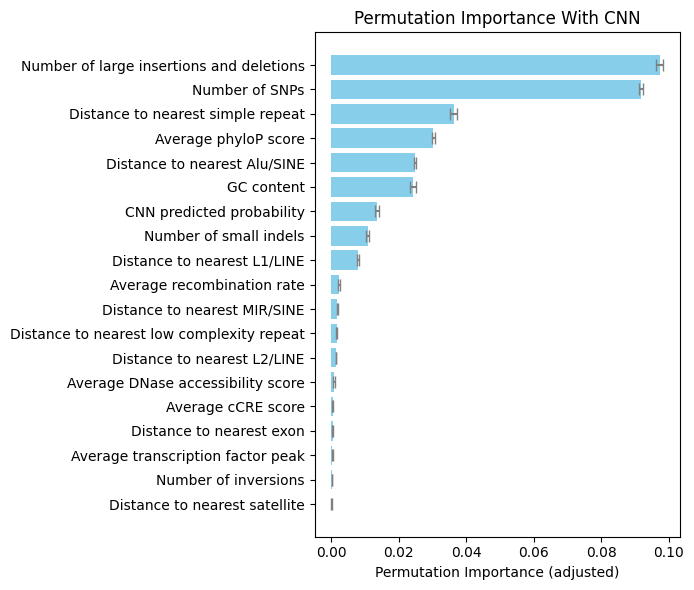

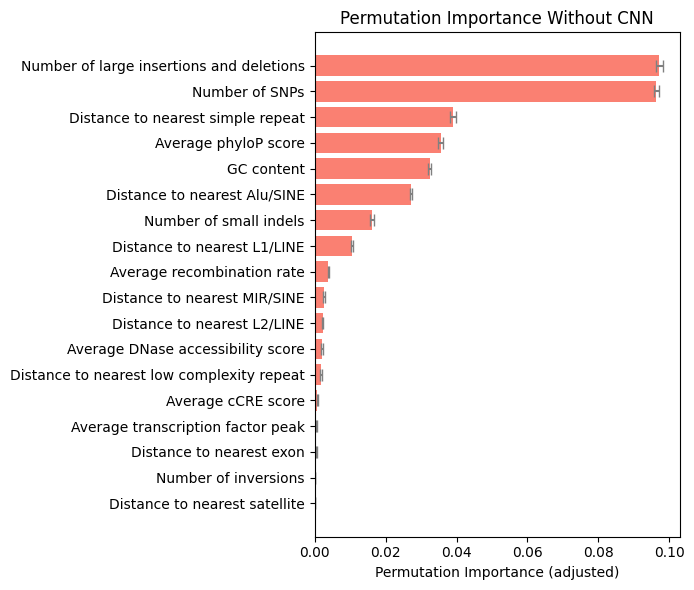

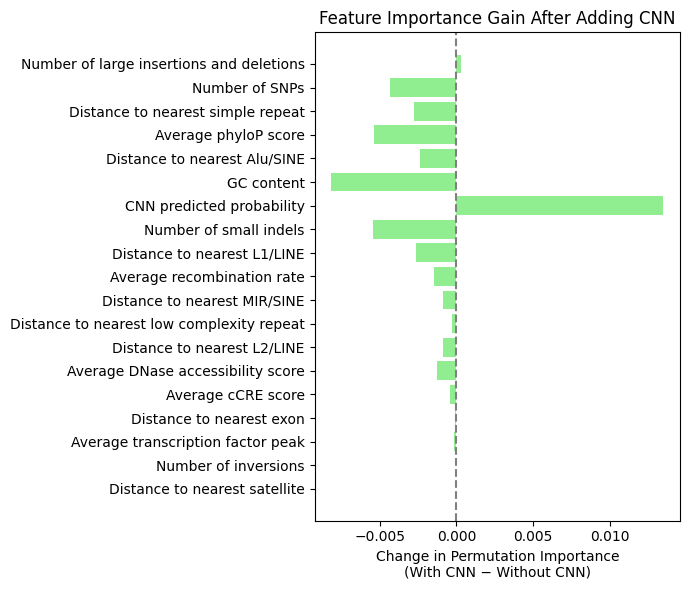

In [ ]:
is_cnn = importances_merged["feature"] == "CNN predicted probability"

sum_with_shared = importances_merged.loc[~is_cnn, "importance_mean_with_cnn"].sum()
sum_no_cnn = importances_merged.loc[~is_cnn, "importance_mean_no_cnn"].sum()

# Shared feature normalization
importances_merged.loc[~is_cnn, "norm_with_cnn_adj"] = (
    importances_merged.loc[~is_cnn, "importance_mean_with_cnn"] 
)
importances_merged.loc[~is_cnn, "norm_no_cnn_adj"] = (
    importances_merged.loc[~is_cnn, "importance_mean_no_cnn"] 
)

total_with = importances_merged["importance_mean_with_cnn"].sum()
importances_merged.loc[is_cnn, "norm_with_cnn_adj"] = (
    importances_merged.loc[is_cnn, "importance_mean_with_cnn"] / total_with
)
importances_merged.loc[is_cnn, "norm_no_cnn_adj"] = 0  # CNN does not exist pre-CNN

# Delta
importances_merged["delta_adj"] = (
    importances_merged["norm_with_cnn_adj"] - importances_merged["norm_no_cnn_adj"]
)

sorted_imp = importances_merged.sort_values(by="norm_with_cnn_adj", ascending=True)
features = sorted_imp["feature"]
y_pos = np.arange(len(features))

# Plot 1: With CNN
plt.figure(figsize=(7, 6))
plt.barh(
    y_pos, sorted_imp["norm_with_cnn_adj"],
    xerr=sorted_imp["importance_std_with_cnn"],
    align="center", color="skyblue", ecolor="gray", capsize=4
)
plt.yticks(y_pos, features)
plt.xlabel("Permutation Importance (adjusted)")
plt.title("Permutation Importance With CNN")
plt.tight_layout()
plt.savefig(f"{species}/{species}_{window_abbr}kb_feature_impt_with_CNN_{subset_str}.pdf", format="pdf")
plt.show()

# Plot 2: Without CNN
sorted_no_cnn = importances_merged.loc[~is_cnn].sort_values(by="norm_no_cnn_adj", ascending=True)
features_no_cnn = sorted_no_cnn["feature"]
y_pos_no_cnn = np.arange(len(features_no_cnn))

plt.figure(figsize=(7, 6))
plt.barh(
    y_pos_no_cnn, sorted_no_cnn["norm_no_cnn_adj"],
    xerr=sorted_no_cnn["importance_std_no_cnn"],
    align="center", color="salmon", ecolor="gray", capsize=4
)
plt.yticks(y_pos_no_cnn, features_no_cnn)
plt.xlabel("Permutation Importance (adjusted)")
plt.title("Permutation Importance Without CNN")
plt.tight_layout()
plt.savefig(f"{species}/{species}_{window_abbr}kb_feature_impt_no_CNN_{subset_str}.pdf", format="pdf")
plt.show()

# Plot 3: Adjusted importance delta
ordered_features = sorted_imp["feature"]
delta_ordered = importances_merged.set_index("feature").reindex(
    ordered_features
)["delta_adj"].fillna(0)

plt.figure(figsize=(7, 6))
plt.barh(y_pos, delta_ordered, color="lightgreen")
plt.axvline(0, color="gray", linestyle="--")
plt.yticks(y_pos, ordered_features)
plt.xlabel("Change in Permutation Importance\n(With CNN − Without CNN)")
plt.title("Feature Importance Gain After Adding CNN")
plt.tight_layout()
plt.savefig(f"{species}/{species}_{window_abbr}kb_feature_impt_gain_from_CNN_{subset_str}.pdf", format="pdf")
plt.show()

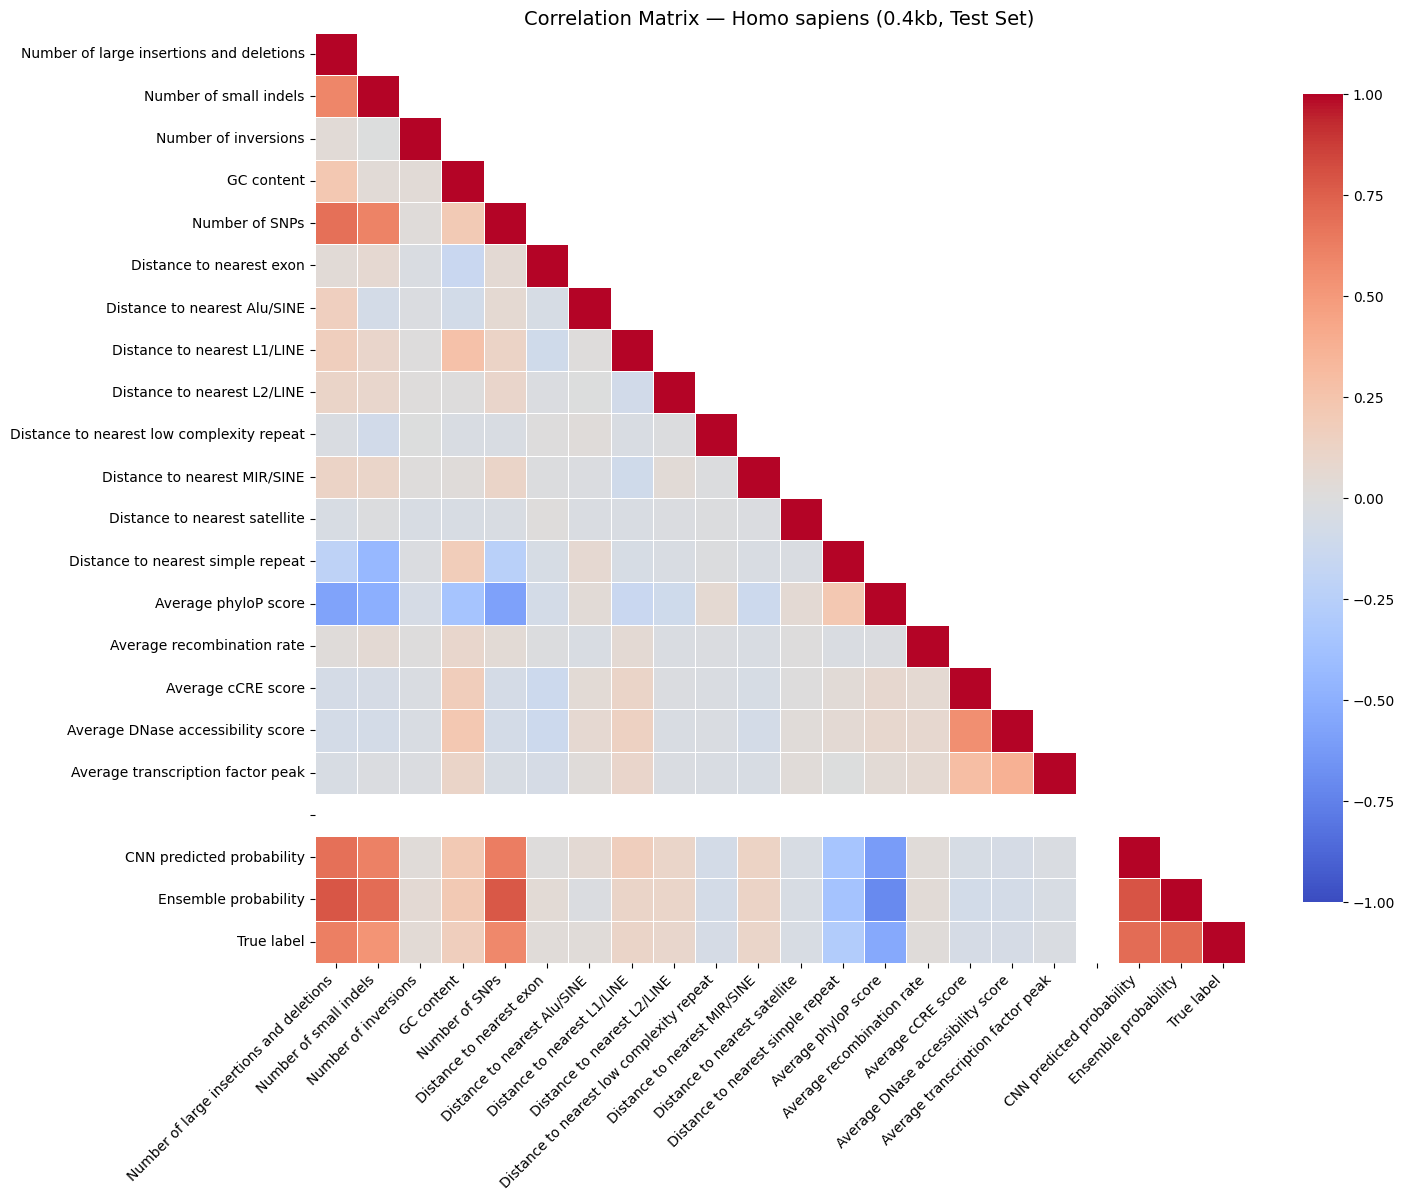

[saved] correlation matrix → Homo_sapiens/Homo_sapiens_0.4kb_correlation_matrix_tri_combined_t.pdf


In [ ]:
test_df = pd.DataFrame(
    X_test_extended,
    columns=num_feature_cols_with_cnn
)

test_df["RF probability"] = y_probs_pre
test_df["Ensemble probability"] = y_probs
test_df["True label"] = y_test

meta_cols = ["CNN predicted probability", "Ensemble probability", "True label"]
feature_cols = [c for c in test_df.columns if c not in meta_cols]

gap = " " 

# Correlation matrix
corr_matrix = test_df[feature_cols + meta_cols].corr(method="spearman")
n_feat = len(feature_cols)

corr_matrix.insert(n_feat, gap, np.nan)
corr_matrix.loc[gap] = np.nan

new_order = [*feature_cols, gap, *meta_cols]
corr_matrix = corr_matrix.reindex(new_order, axis=0)
corr_matrix = corr_matrix.reindex(new_order, axis=1)

# Mask upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(15, 15))
ax = sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": .7}
)

n = corr_matrix.shape[0]
tick_positions = np.arange(n) + 0.5

ax.set_xticks(tick_positions)
ax.set_yticks(tick_positions)

tick_labels = ["" if c == gap else c for c in corr_matrix.columns]
ax.set_xticklabels(tick_labels, rotation=45, ha='right')
ax.set_yticklabels(tick_labels, rotation=0)

plt.title(f"Correlation Matrix — {species_space} ({window_abbr}kb, Test Set)", fontsize=14)

out_pdf = f"{species}/{species}_{window_abbr}kb_correlation_matrix_tri_{subset_str}.pdf"
plt.savefig(out_pdf, format="pdf", bbox_inches='tight', dpi=300)
plt.show()

print(f"[saved] correlation matrix → {out_pdf}")
test_df.to_csv(f"{species}/{species}_{window_abbr}kb_test_df_{subset_str}.csv", index=False)

### DeepSHAP

In [ ]:
model.eval()
model.to(device)

background_size = 500
target_size = 3500

rng = np.random.default_rng(SEED)

bg_idx = rng.choice(len(X_cat_train_tensor), size=background_size, replace=False)
target_idx = rng.choice(len(X_cat_test_tensor), size=target_size, replace=False)

background = X_cat_train_tensor[bg_idx].clone().detach().to(device)
targets = X_cat_test_tensor[target_idx].clone().detach().to(device)

target_meta = test_meta.iloc[target_idx].reset_index(drop=True).copy()

explainer = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(targets)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.asarray(shap_values)

if shap_values.ndim == 4:
    shap_values = shap_values.squeeze(-1)

print("targets:", targets.shape)
print("shap:", shap_values.shape)

ohe = targets.detach().cpu().numpy()
contrib_scores = shap_values * ohe
base_importance = contrib_scores.sum(axis=1)

print("base importance:", base_importance.shape)

In [ ]:
out_prefix = f"{species}/{species}_{window_abbr}kb_sv"
modisco_dir = f"{species}/modisco_by_repeat_group"
os.makedirs(modisco_dir, exist_ok=True)

def rename(x):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(x))

groups = target_meta["REPEAT_GROUP"].dropna().unique()

for group in groups:
    group_mask = (
        (target_meta["REPEAT_GROUP"] == group) &
        (target_meta["label"] == 1)
    ).to_numpy()

    n = group_mask.sum()

    group_name = rename(group)
    group_prefix = f"{modisco_dir}/{species}_{window_abbr}kb_{group_name}"

    ohe_group = ohe[group_mask].astype(np.float32)
    shap_group = contrib_scores[group_mask].astype(np.float32)
    meta_group = target_meta.loc[group_mask].copy()

    np.savez_compressed(
        f"{group_prefix}_ohe.npz",
        arr_0=ohe_group
    )

    np.savez_compressed(
        f"{group_prefix}_shap.npz",
        arr_0=shap_group
    )

    meta_group.to_csv(
        f"{group_prefix}_metadata.csv",
        index=False
    )

    print(f"Running MoDISco for {group} with {n} positives")
    
    if n > 0:
        !modisco motifs \
        -s {group_prefix}_ohe.npz \
        -a {group_prefix}_shap.npz \
        -n {min(2000, n)} \
        -o {group_prefix}_modisco_results.h5

print(group_prefix)

ohe_loaded = np.load(f"{group_prefix}_ohe.npz")["arr_0"]
shap_loaded = np.load(f"{group_prefix}_shap.npz")["arr_0"]

print(ohe_loaded.shape)
print(shap_loaded.shape)

In [ ]:
def top_regions(seq, importance, window=20, top_n=5):
    rows = []

    for i in range(len(seq) - window):
        score = np.sum(np.abs(importance[i:i+window]))

        rows.append({
            "start": i,
            "end": i + window,
            "score": score,
            "subsequence": seq[i:i+window]
        })

    return pd.DataFrame(rows).sort_values("score", ascending=False).head(top_n)

k = 6
top_windows_per_seq = 3
window_size = 20

for group in sorted(target_meta["REPEAT_GROUP"].dropna().unique()):

    mask = (
        (target_meta["REPEAT_GROUP"] == group) &
        (target_meta["label"] == 1)
    ).to_numpy()

    if mask.sum() < 10:
        continue

    kmers = Counter()

    for idx in np.where(mask)[0]:

        hits = top_regions(
            seq=target_meta.loc[idx, "sequence"],
            importance=base_importance[idx],
            window=window_size,
            top_n=top_windows_per_seq
        )

        for subseq in hits["subsequence"]:

            for i in range(len(subseq) - k + 1):
                kmers[subseq[i:i+k]] += 1

    print(f"\n=== {group} (n={mask.sum()}) ===")

    display(
        pd.DataFrame(
            kmers.most_common(20),
            columns=["motif", "count"]
        )
    )


=== LINE/L1 (n=51) ===


,motif,count
0,ATATAT,26
1,TATATA,24
2,TTTTTT,21
3,ATTTTT,13
4,TTTTTC,13
5,TAAATA,12
6,ATAAAT,11
7,AAAAAA,11
8,CAATAA,10
9,AAATAA,10



=== Non-repetitive (n=931) ===


,motif,count
0,ATATAT,646
1,TATATA,637
2,TTTTTT,244
3,AATATA,157
4,TATATT,157
5,TTATAT,147
6,ATATAA,144
7,ACACAC,126
8,TATAAT,122
9,GTGTGT,118



=== Others (n=123) ===


...

,motif,count
0,AAAAAA,176
1,TTTTTT,102
2,TAAAAA,55
3,AAAAAT,52
4,TTTTTA,47
5,AAAAGA,44
6,ATTTTT,44
7,AAAAAG,41
8,TTAAAA,40
9,AAGAAA,39



=== Simple_repeat (n=374) ===


,motif,count
0,ATATAT,1205
1,TATATA,1178
2,AATATA,199
3,TTATAT,182
4,TTCTTT,178
5,TTTCTT,175
6,ATATAA,173
7,TATATT,169
8,TCTTTC,139
9,TTTTTT,135



=== Unknown (n=70) ===


,motif,count
0,TATATA,221
1,ATATAT,194
2,TGTATA,98
3,GTATAT,80
4,TATACA,79
5,ATATGT,77
6,ATGTAT,69
7,ACACAC,66
8,ATATAC,65
9,TATGTA,63


In [ ]:
k = 6

for group in sorted(target_meta["REPEAT_GROUP"].dropna().unique()):

    mask = (
        (target_meta["REPEAT_GROUP"] == group) &
        (target_meta["label"] == 1)
    ).to_numpy()

    motif_scores = defaultdict(float)

    for idx in np.where(mask)[0]:
        hits = top_regions(
            seq=target_meta.loc[idx, "sequence"],
            importance=base_importance[idx],
            window=20,
            top_n=3
        )

        for _, row in hits.iterrows():
            subseq = row["subsequence"]
            score = row["score"]

            for i in range(len(subseq) - k + 1):
                motif_scores[subseq[i:i+k]] += score

    top = (
        pd.Series(motif_scores)
        .sort_values(ascending=False)
        .head(20)
    )

    print(f"\n=== {group} ===")
    display(top.to_frame("importance_score"))


=== LINE/L1 ===


,importance_score
TTTTTT,7.749002
TTTTTC,4.827151
ATATAT,4.243584
ATTTTT,3.986911
TATATA,3.922416
TAAATA,3.477094
TAAATG,3.295304
CAATAA,3.280195
AAAAAA,3.135211
AAATGG,3.028560



=== Non-repetitive ===


,importance_score
ATATAT,71.280839
TATATA,70.189731
TTTTTT,57.968107
CCTCCC,20.513661
AAAAAA,18.337727
AATATA,17.466040
TATATT,17.394194
TTATAT,16.722784
ATATAA,16.004947
GTGTGT,15.227314



=== Others ===


...

,importance_score
ATATAT,133.799025
TATATA,130.613364
TTCTTT,25.595058
TTTCTT,25.300324
TTTTTT,22.081327
AATATA,21.306027
TCTTTC,19.928160
TTATAT,19.440477
TATATT,18.668972
CTTTCT,18.471484



=== Unknown ===


,importance_score
TATATA,23.642466
ATATAT,20.716232
TGTATA,9.732768
TATACA,8.473410
GTATAT,7.947719
ATATGT,7.803553
ATATAC,7.195645
ACACAC,6.808339
ATGTAT,6.779451
TATGTA,6.327006



=== nonRepeat ===


,importance_score
CCAGGA,1.436691
CAGGAA,1.436691
CATCCA,1.436691
ATCCAG,1.436691
TCCAGG,1.436691
TGTACC,1.436691
GTACCA,1.436691
TACCAT,1.436691
ACCATC,1.436691
CCATCC,1.436691


In [ ]:
def motif_position_heatmap(
    group,
    motifs,
    target_meta,
    base_importance,
    bin_size=10,
    flank=200,
    label_only=True
):
    mask = target_meta["REPEAT_GROUP"].eq(group)

    if label_only:
        mask &= target_meta["label"].eq(1)

    idxs = np.where(mask.to_numpy())[0]

    bins = np.arange(-flank, flank + bin_size, bin_size)
    heat = pd.DataFrame(
        0.0,
        index=motifs,
        columns=[f"{bins[i]}:{bins[i+1]}" for i in range(len(bins)-1)]
    )

    for idx in idxs:
        seq = target_meta.loc[idx, "sequence"]
        imp = base_importance[idx]
        center = len(seq) // 2

        for motif in motifs:
            for m in re.finditer(f"(?={motif})", seq):
                pos = m.start()
                rel = pos - center

                if rel < -flank or rel >= flank:
                    continue

                score = np.sum(np.abs(imp[pos:pos+len(motif)]))
                bin_idx = np.searchsorted(bins, rel, side="right") - 1
                heat.iloc[heat.index.get_loc(motif), bin_idx] += score

    # row-normalize so each motif shows positional preference
    heat_norm = heat.copy() # np.log1p(heat) # heat.div(heat.max(axis=1).replace(0, np.nan), axis=0).fillna(0)
    vmax = np.percentile(heat.values, 99)

    plt.figure(figsize=(14, max(3, 0.35 * len(motifs))))
    plt.imshow(
        heat_norm,
        aspect="auto",
        interpolation="nearest",
        cmap="hot",
        vmin=0,
        vmax=vmax
    )
    plt.colorbar(label="Normalized attribution")
    plt.yticks(np.arange(len(motifs)), motifs)
    plt.xticks(
        np.arange(0, len(heat_norm.columns), max(1, len(heat_norm.columns)//10)),
        [heat_norm.columns[i] for i in range(0, len(heat_norm.columns), max(1, len(heat_norm.columns)//10))],
        rotation=45,
        ha="right"
    )
    plt.axvline(len(heat_norm.columns)//2, color="red", linestyle="--", linewidth=1)
    plt.title(f"{group_rename(group)}: motif position × attribution heatmap, n={len(idxs)}")
    plt.xlabel("Position relative to breakpoint")
    plt.ylabel("Motif")
    plt.tight_layout()
    plt.savefig(f"{species}/{species}_{window_abbr}kb_deepshap_tfmodisco_{str(group).replace('/', '')}_{subset_str}.pdf", format='pdf', bbox_inches='tight', dpi=300)
    plt.show()

    return heat, heat_norm

def group_rename(group):
    group = str(group)

    if group == "Simple_repeat":
        return "Simple repeat"

    if group == "nonRepeat":
        return "non-Repeat"

    return group.replace("_", " ")

motifs = ["TAAA", "TTTA", "AAAA", "TATT"]

for group in sorted(target_meta["REPEAT_GROUP"].dropna().unique()):
    motif_position_heatmap(
        group=group,
        motifs=motifs,
        target_meta=target_meta,
        base_importance=base_importance,
        bin_size=10,
        flank=200
    )